# **3 ВАРИАНТ** Танюшкин А.Л.

# Лабораторная работа № 1. Регрессия на основе нейронных сетей
	Цель лабораторной работы – получение навыков работы с моделями глубоких нейронных сетей для решения задачи регрессии.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer

1. Написать какую задачу вы будете решать на словах и какую колонку будет прогнозировать ваша модель. 

price_doc в файле train.csv

2.	В каждой паке лежат файлы: train.csv, test.csv для обучения и теста соответственно.

...

3.	Выполнить команды: head, tail, info, describe, shape на каждом наборе и на тесте и на обучении.

In [2]:
data_test = pd.read_csv('test.csv', sep=',')
data_test.head()

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,...,cafe_count_5000_price_1500,cafe_count_5000_price_2500,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000
0,30474,2015-07-01,39.0,20.7,2,9,1,1998.0,1,8.9,...,8,0,0,0,1,10,1,0,14,1
1,30475,2015-07-01,79.2,NaN,8,17,1,0.0,3,1.0,...,4,1,1,0,2,11,0,1,12,1
2,30476,2015-07-01,40.5,25.1,3,5,2,1960.0,2,4.8,...,42,11,4,0,10,21,0,10,71,11
3,30477,2015-07-01,62.8,36.0,17,17,1,2016.0,2,62.8,...,1,1,2,0,0,10,0,0,2,0
4,30478,2015-07-01,40.0,40.0,17,17,1,0.0,1,1.0,...,5,1,1,0,2,12,0,1,11,1


In [3]:
data_test.tail()

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,...,cafe_count_5000_price_1500,cafe_count_5000_price_2500,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000
7657,38131,2016-05-26,52.20,31.8,10,12,5,1973.0,2,9.1,...,81,28,1,1,8,39,2,3,75,12
7658,38132,2016-05-28,54.09,NaN,14,0,1,NaN,2,0.0,...,1,2,1,0,0,10,0,0,0,0
7659,38133,2016-05-30,41.08,1.0,12,1,1,1.0,1,1.0,...,636,371,141,26,150,249,2,105,203,13
7660,38134,2016-05-30,34.80,19.8,8,9,5,1977.0,1,6.4,...,16,7,2,0,5,11,0,2,43,10
7661,38135,2016-05-30,63.00,43.8,5,5,1,1973.0,3,7.1,...,31,11,1,0,6,26,1,4,42,11


In [4]:
data_test.describe()

,id,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,...,cafe_count_5000_price_1500,cafe_count_5000_price_2500,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000
count,7662.000000,7662.000000,6486.000000,7662.000000,7662.000000,7662.000000,6613.000000,7662.000000,7662.000000,6968.000000,...,7662.000000,7662.000000,7662.000000,7662.000000,7662.000000,7662.000000,7662.000000,7662.000000,7662.000000,7662.000000
mean,34304.500000,53.701164,32.660037,7.652571,12.591099,1.854216,1820.888099,1.876403,6.938662,1.985792,...,69.532890,35.777865,12.152310,2.007439,16.749152,33.109371,0.412425,9.639650,56.235839,6.330723
std,2211.973214,20.104320,22.737855,5.099418,6.659291,1.517171,552.993964,0.835665,25.579688,0.820086,...,129.533773,76.524992,29.590097,5.664540,30.706709,49.734993,0.608938,21.499687,47.632547,4.956223
min,30474.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32389.250000,39.200000,19.900000,4.000000,9.000000,1.000000,1966.000000,1.000000,1.000000,1.000000,...,7.000000,2.000000,1.000000,0.000000,3.000000,10.000000,0.000000,0.000000,12.000000,2.000000
50%,34304.500000,50.410000,30.400000,7.000000,14.000000,1.000000,1982.000000,2.000000,7.000000,2.000000,...,27.000000,10.000000,2.000000,0.000000,7.000000,17.000000,0.000000,2.000000,51.000000,5.000000
75%,36219.750000,63.300000,41.800000,11.000000,17.000000,2.000000,2011.000000,2.000000,9.500000,3.000000,...,54.000000,25.000000,5.000000,1.000000,13.000000,29.000000,1.000000,7.000000,79.000000,11.000000
max,38135.000000,403.000000,869.000000,41.000000,48.000000,6.000000,2019.000000,19.000000,1968.000000,4.000000,...,643.000000,374.000000,145.000000,29.000000,150.000000,249.000000,2.000000,105.000000,212.000000,21.000000


In [5]:
data_test.shape

(7662, 291)

In [6]:
data_train = pd.read_csv('train.csv', sep=',')
data_train.head()

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,...,cafe_count_5000_price_2500,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000,price_doc
0,1,2011-08-20,43,27.0,4.0,NaN,NaN,NaN,NaN,NaN,...,9,4,0,13,22,1,0,52,4,5850000
1,2,2011-08-23,34,19.0,3.0,NaN,NaN,NaN,NaN,NaN,...,15,3,0,15,29,1,10,66,14,6000000
2,3,2011-08-27,43,29.0,2.0,NaN,NaN,NaN,NaN,NaN,...,10,3,0,11,27,0,4,67,10,5700000
3,4,2011-09-01,89,50.0,9.0,NaN,NaN,NaN,NaN,NaN,...,11,2,1,4,4,0,0,26,3,13100000
4,5,2011-09-05,77,77.0,4.0,NaN,NaN,NaN,NaN,NaN,...,319,108,17,135,236,2,91,195,14,16331452


In [7]:
data_train.tail()

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,...,cafe_count_5000_price_2500,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000,price_doc
30466,30469,2015-06-30,44,27.0,7.0,9.0,1.0,1975.0,2.0,6.0,...,15,5,0,15,26,1,2,84,6,7400000
30467,30470,2015-06-30,86,59.0,3.0,9.0,2.0,1935.0,4.0,10.0,...,313,128,24,98,182,1,82,171,15,25000000
30468,30471,2015-06-30,45,NaN,10.0,20.0,1.0,NaN,1.0,1.0,...,1,1,0,2,12,0,1,11,1,6970959
30469,30472,2015-06-30,64,32.0,5.0,15.0,1.0,2003.0,2.0,11.0,...,22,1,1,6,31,1,4,65,7,13500000
30470,30473,2015-06-30,43,28.0,1.0,9.0,1.0,1968.0,2.0,6.0,...,5,2,0,7,16,0,9,54,10,5600000


In [8]:
data_train.describe()

,id,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,...,cafe_count_5000_price_2500,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000,price_doc
count,30471.000000,30471.000000,24088.000000,30304.000000,20899.000000,20899.000000,1.686600e+04,20899.000000,20899.000000,16912.000000,...,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000,3.047100e+04
mean,15237.917397,54.214269,34.403271,7.670803,12.558974,1.827121,3.068057e+03,1.909804,6.399301,2.107025,...,32.058318,10.783860,1.771783,15.045552,30.251518,0.442421,8.648814,52.796593,5.987070,7.123035e+06
std,8796.501536,38.031487,52.285733,5.319989,6.756550,1.481154,1.543878e+05,0.851805,28.265979,0.880148,...,73.465611,28.385679,5.418807,29.118668,47.347938,0.609269,20.580741,46.292660,4.889219,4.780111e+06
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000e+00,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+05
25%,7620.500000,38.000000,20.000000,3.000000,9.000000,1.000000,1.967000e+03,1.000000,1.000000,1.000000,...,2.000000,1.000000,0.000000,2.000000,9.000000,0.000000,0.000000,11.000000,1.000000,4.740002e+06
50%,15238.000000,49.000000,30.000000,6.500000,12.000000,1.000000,1.979000e+03,2.000000,6.000000,2.000000,...,8.000000,2.000000,0.000000,7.000000,16.000000,0.000000,2.000000,48.000000,5.000000,6.274411e+06
75%,22855.500000,63.000000,43.000000,11.000000,17.000000,2.000000,2.005000e+03,2.000000,9.000000,3.000000,...,21.000000,5.000000,1.000000,12.000000,28.000000,1.000000,7.000000,76.000000,10.000000,8.300000e+06
max,30473.000000,5326.000000,7478.000000,77.000000,117.000000,6.000000,2.005201e+07,19.000000,2014.000000,33.000000,...,377.000000,147.000000,30.000000,151.000000,250.000000,2.000000,106.000000,218.000000,21.000000,1.111111e+08


In [9]:
data_train.shape

(30471, 292)

4.	Преобразование данных: здесь вам надо будет подготовить данные к обучению, например: (всё делается на ваше усмотрение в пределах разумного, я могу спросить а сколько данных было удалено и если удалено 80% обучающих данных, то это не решение, а дрянь, поэтому вы должны уметь обосновать ваши решения по предобработке)

a.	Удалить дубликаты, пропуски

b.	Заполнить пропуски

c.	Кодирование фичей label or onehot

d.	Скэйлинг фичей

e.	Удаление коррелирующих признаков

f.	Удаление мусорных данных (типа id)



In [10]:
data_train.head(1)

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,...,cafe_count_5000_price_2500,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000,price_doc
0,1,2011-08-20,43,27.0,4.0,NaN,NaN,NaN,NaN,NaN,...,9,4,0,13,22,1,0,52,4,5850000


In [11]:
def missing_data(df):
    miss = (df.isna().sum() / len(df)) * 100

    miss_info = pd.DataFrame({
        'столбец': df.columns,
        'число пропусков': df.isna().sum().values,
        'процент': ((df.isna().sum() / len(df)) * 100).values
    })

    pd.set_option('display.max_rows', None)
    print(miss_info.sort_values('число пропусков', ascending=False))
    pd.reset_option('display.max_rows')

In [12]:
missing_data(data_train)

                                   столбец  число пропусков    процент
24                     hospital_beds_raion            14441  47.392603
7                               build_year            13605  44.649011
10                                   state            13559  44.498047
161             cafe_sum_500_max_price_avg            13281  43.585704
162                     cafe_avg_price_500            13281  43.585704
160             cafe_sum_500_min_price_avg            13281  43.585704
8                                 num_room             9572  31.413475
9                                 kitch_sq             9572  31.413475
5                                max_floor             9572  31.413475
6                                 material             9572  31.413475
18                         preschool_quota             6688  21.948738
21                            school_quota             6685  21.938893
184            cafe_sum_1000_max_price_avg             6524  21.410521
183   

In [13]:
missing_data(data_test)

                                   столбец  число пропусков    процент
24                     hospital_beds_raion             3418  44.609762
160             cafe_sum_500_min_price_avg             3159  41.229444
161             cafe_sum_500_max_price_avg             3159  41.229444
162                     cafe_avg_price_500             3159  41.229444
18                         preschool_quota             1596  20.830070
21                            school_quota             1595  20.817019
185                    cafe_avg_price_1000             1222  15.948838
183            cafe_sum_1000_min_price_avg             1222  15.948838
184            cafe_sum_1000_max_price_avg             1222  15.948838
83                  build_count_after_1995             1218  15.896633
82                   build_count_1971-1995             1218  15.896633
81                   build_count_1946-1970             1218  15.896633
80                   build_count_1921-1945             1218  15.896633
79    

In [14]:
data_test_new = data_test.copy()
data_train_new = data_train.copy()

a.	Удалить дубликаты, пропуски - f.	Удаление мусорных данных (типа id)

In [15]:
def pred_obr(df):
    #удаление дубликатов
    df.drop_duplicates(inplace=True)
    
    columns_drop = [
        #удаление данных с большим кол-вом пропусков +мусорный
        'hospital_beds_raion',
        #удаление мусорных данных
        'id',
        'timestamp',
    ]

    df.drop(columns_drop, axis=1, inplace=True)

    return df

        'cafe_sum_500_min_price_avg',
        'cafe_sum_500_max_price_avg',
        'cafe_avg_price_500',
        'cafe_count_500_na_price',
        'cafe_count_500_price_500',
        'cafe_count_500_price_1000',
        'cafe_count_500_price_1500',
        'cafe_count_500_price_2500',
        'cafe_count_500_price_4000',
        'cafe_count_500_price_high',
        'cafe_sum_1000_min_price_avg',
        'cafe_sum_1000_max_price_avg',
        'cafe_avg_price_1000',
        'cafe_count_1000_na_price',
        'cafe_count_1000_price_500',
        'cafe_count_1000_price_1000',
        'cafe_count_1000_price_1500',
        'cafe_count_1000_price_2500',
        'cafe_count_1000_price_4000',
        'cafe_count_1000_price_high',
        'cafe_sum_1500_min_price_avg',
        'cafe_sum_1500_max_price_avg',
        'cafe_avg_price_1500',
        'cafe_count_1500_na_price',
        'cafe_count_1500_price_500',
        'cafe_count_1500_price_1000',
        'cafe_count_1500_price_1500',
        'cafe_count_1500_price_2500',
        'cafe_count_1500_price_4000',
        'cafe_count_1500_price_high',
        'cafe_sum_2000_min_price_avg',
        'cafe_sum_2000_max_price_avg',
        'cafe_avg_price_2000',
        'cafe_count_2000_na_price',
        'cafe_count_2000_price_500',
        'cafe_count_2000_price_1000',
        'cafe_count_2000_price_1500',
        'cafe_count_2000_price_2500',
        'cafe_count_2000_price_4000',
        'cafe_count_2000_price_high',
        'cafe_sum_3000_min_price_avg',
        'cafe_sum_3000_max_price_avg',
        'cafe_avg_price_3000',
        'cafe_count_3000_na_price',
        'cafe_count_3000_price_500',
        'cafe_count_3000_price_1000',
        'cafe_count_3000_price_1500',
        'cafe_count_3000_price_2500',
        'cafe_count_3000_price_4000',
        'cafe_count_3000_price_high',
        'cafe_sum_5000_min_price_avg',
        'cafe_sum_5000_max_price_avg',
        'cafe_avg_price_5000',
        'cafe_count_5000_na_price',
        'cafe_count_5000_price_500',
        'cafe_count_5000_price_1000',
        'cafe_count_5000_price_1500',
        'cafe_count_5000_price_2500',
        'cafe_count_5000_price_4000',
        'cafe_count_5000_price_high',

In [16]:
pred_obr(data_test_new)
pred_obr(data_train_new)

,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,product_type,...,cafe_count_5000_price_2500,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000,price_doc
0,43,27.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,Investment,...,9,4,0,13,22,1,0,52,4,5850000
1,34,19.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,Investment,...,15,3,0,15,29,1,10,66,14,6000000
2,43,29.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,Investment,...,10,3,0,11,27,0,4,67,10,5700000
3,89,50.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,Investment,...,11,2,1,4,4,0,0,26,3,13100000
4,77,77.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,Investment,...,319,108,17,135,236,2,91,195,14,16331452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30466,44,27.0,7.0,9.0,1.0,1975.0,2.0,6.0,3.0,Investment,...,15,5,0,15,26,1,2,84,6,7400000
30467,86,59.0,3.0,9.0,2.0,1935.0,4.0,10.0,3.0,Investment,...,313,128,24,98,182,1,82,171,15,25000000
30468,45,NaN,10.0,20.0,1.0,NaN,1.0,1.0,1.0,OwnerOccupier,...,1,1,0,2,12,0,1,11,1,6970959
30469,64,32.0,5.0,15.0,1.0,2003.0,2.0,11.0,2.0,Investment,...,22,1,1,6,31,1,4,65,7,13500000


In [17]:
missing_data(data_train_new)

                                   столбец  число пропусков    процент
5                               build_year            13605  44.649011
8                                    state            13559  44.498047
159                     cafe_avg_price_500            13281  43.585704
158             cafe_sum_500_max_price_avg            13281  43.585704
157             cafe_sum_500_min_price_avg            13281  43.585704
6                                 num_room             9572  31.413475
7                                 kitch_sq             9572  31.413475
4                                 material             9572  31.413475
3                                max_floor             9572  31.413475
16                         preschool_quota             6688  21.948738
19                            school_quota             6685  21.938893
180            cafe_sum_1000_min_price_avg             6524  21.410521
181            cafe_sum_1000_max_price_avg             6524  21.410521
182   

b.	Заполнить пропуски

In [18]:
data_test_v2 = data_test_new.copy()
data_train_v2 = data_train_new.copy()

In [19]:
def zapoln(df):

    num_col = df.select_dtypes(include=[np.number]).columns
    
    miss_pers = (df[num_col].isna().sum() / len(df)) * 100
    
    col_less_10 = miss_pers[miss_pers < 10].index
    col_10_30 = miss_pers[(10 <= miss_pers) & (miss_pers < 30)].index
    col_30_50 = miss_pers[(30 <= miss_pers) & (miss_pers <= 50)].index

    if len(col_less_10) > 0:
        simple_imputer = SimpleImputer(strategy='median')
        df[col_less_10] = simple_imputer.fit_transform(df[col_less_10])

    if len(col_10_30) > 0:
        knn_imputer = KNNImputer(n_neighbors=5)
        df[col_10_30] = knn_imputer.fit_transform(df[col_10_30])

    if len(col_30_50) > 0:
        model = IterativeImputer(
            estimator=RandomForestRegressor(
                n_estimators=50,
                max_depth=5,
                random_state=42,
                n_jobs=-1
            ),
            max_iter=10,
            random_state=42,
            initial_strategy='median',
        )
        df[col_30_50] = model.fit_transform(df[col_30_50])

    return df

In [20]:
data_train_v2 = zapoln(data_train_new)
data_test_v2 = zapoln(data_test_new)

In [21]:
missing_data(data_train_v2)

                                   столбец  число пропусков  процент
288                              price_doc                0      0.0
272            cafe_sum_5000_min_price_avg                0      0.0
271                        cafe_count_5000                0      0.0
270                           trc_sqm_5000                0      0.0
269                         trc_count_5000                0      0.0
268                        office_sqm_5000                0      0.0
267                      office_count_5000                0      0.0
266                         prom_part_5000                0      0.0
265                        green_part_5000                0      0.0
264                      market_count_3000                0      0.0
263                       sport_count_3000                0      0.0
262                     leisure_count_3000                0      0.0
261                      mosque_count_3000                0      0.0
260                      church_co

c.	Кодирование фичей label or onehot 

In [22]:
list(data_train_v2.select_dtypes(include=['object']).columns)

['product_type',
 'sub_area',
 'culture_objects_top_25',
 'thermal_power_plant_raion',
 'incineration_raion',
 'oil_chemistry_raion',
 'radiation_raion',
 'railroad_terminal_raion',
 'big_market_raion',
 'nuclear_reactor_raion',
 'detention_facility_raion',
 'water_1line',
 'big_road1_1line',
 'railroad_1line',
 'ecology']

In [23]:
list(data_test_v2.select_dtypes(include=['object']).columns)

['product_type',
 'sub_area',
 'culture_objects_top_25',
 'thermal_power_plant_raion',
 'incineration_raion',
 'oil_chemistry_raion',
 'radiation_raion',
 'railroad_terminal_raion',
 'big_market_raion',
 'nuclear_reactor_raion',
 'detention_facility_raion',
 'water_1line',
 'big_road1_1line',
 'railroad_1line',
 'ecology']

In [24]:
list_obj = ['product_type',
 'culture_objects_top_25',
 'thermal_power_plant_raion',
 'incineration_raion',
 'oil_chemistry_raion',
 'radiation_raion',
 'railroad_terminal_raion',
 'big_market_raion',
 'nuclear_reactor_raion',
 'detention_facility_raion',
 'water_1line',
 'big_road1_1line',
 'railroad_1line',
 ]
    

In [25]:
def obj_in_int(df):
    for obj in list_obj:
        df[obj] = df[obj].apply(lambda x: 1 if str(x).lower() == 'yes' else 0)

    df['sub_area'] = LabelEncoder().fit_transform(df['sub_area'])

    _df = pd.get_dummies(df['ecology'], prefix='ecology')
    df = pd.concat([df.drop('ecology', axis=1), _df], axis=1)

    return df

In [26]:
data_train_v2 = obj_in_int(data_train_v2)
data_test_v2 = obj_in_int(data_test_v2)

e.	Удаление коррелирующих признаков

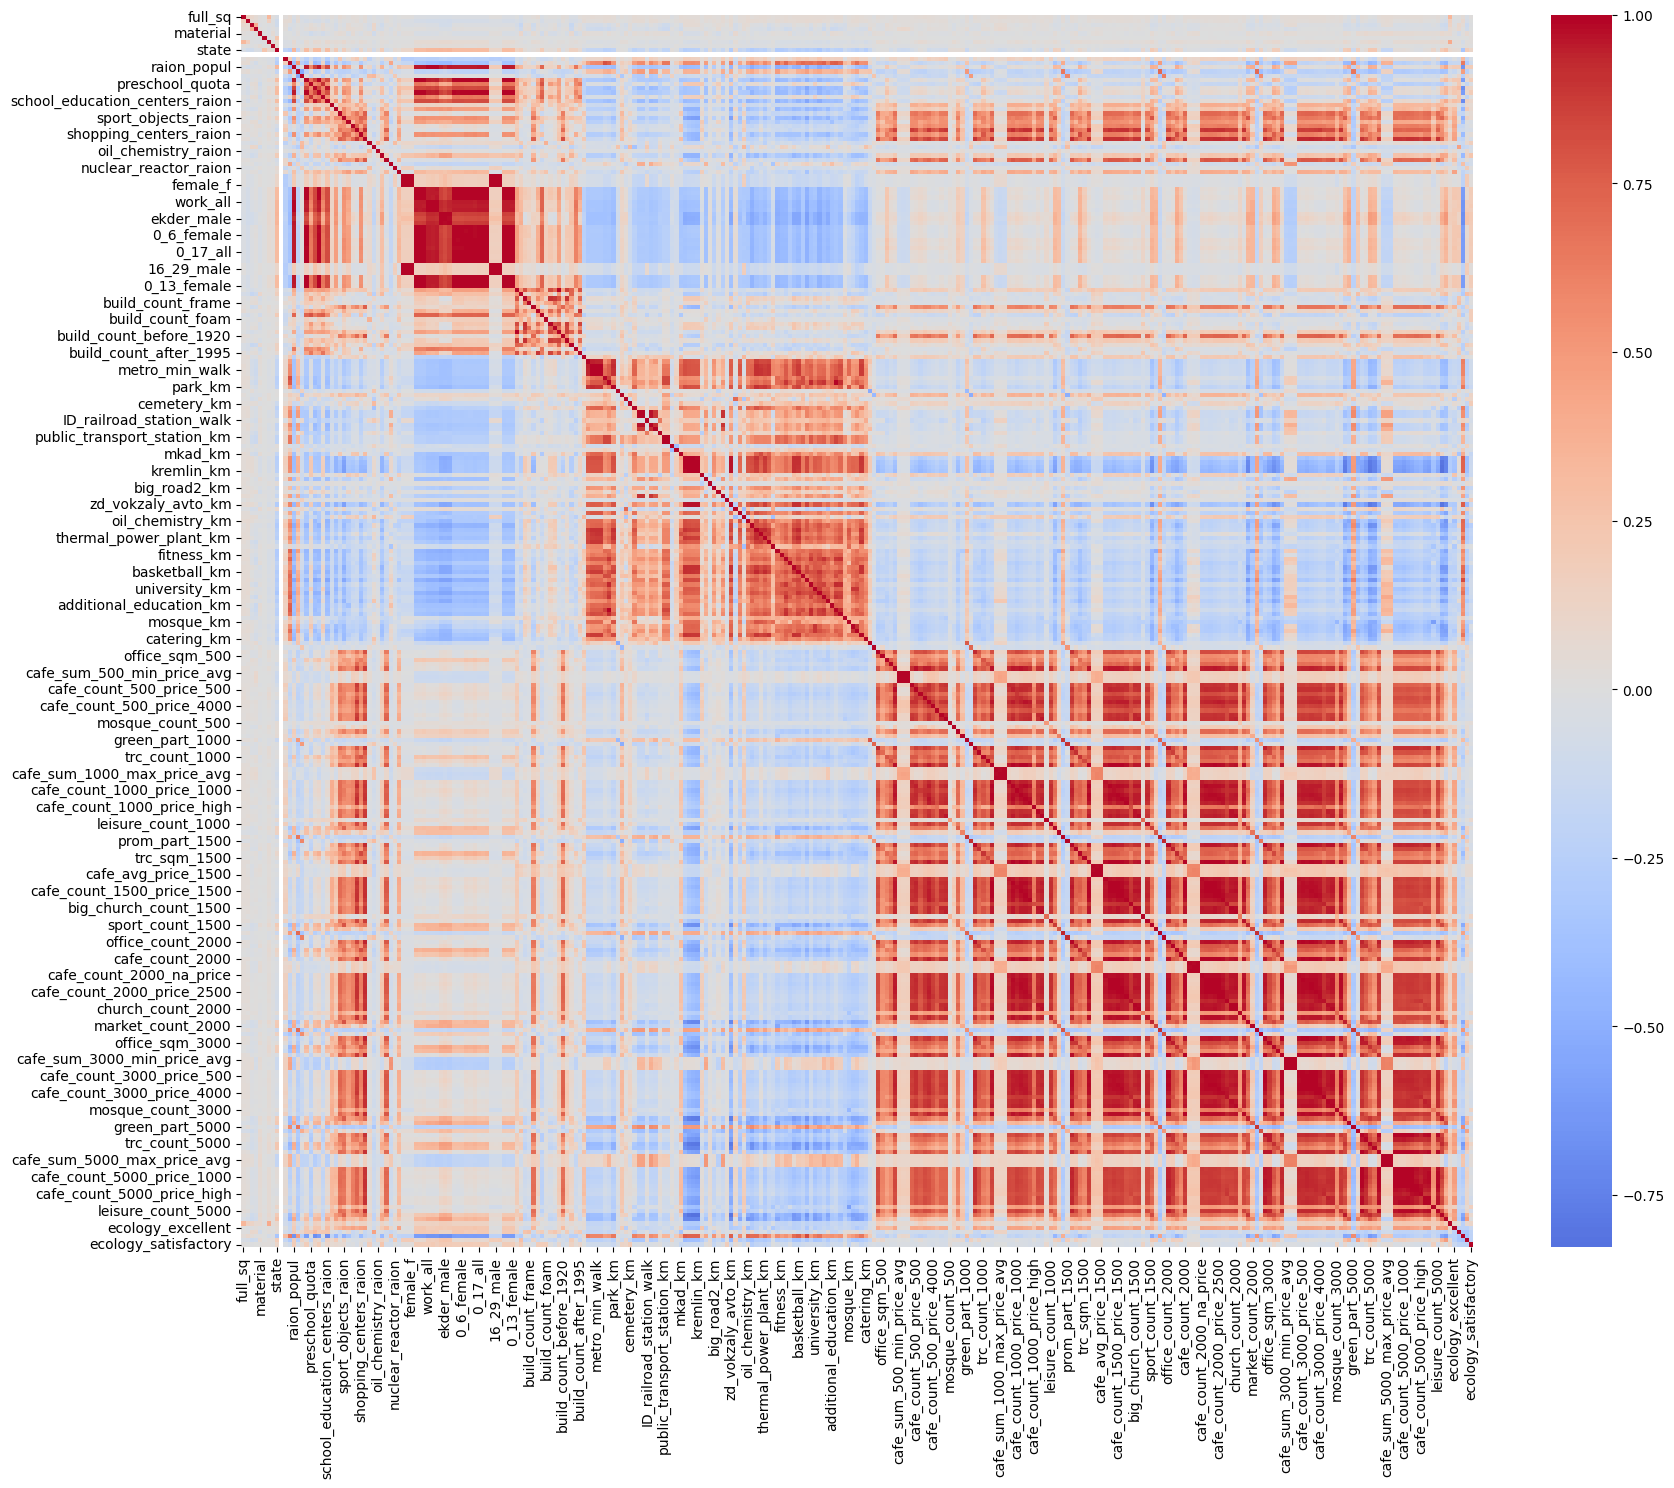

In [27]:
corr_matrix = data_train_v2.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, 
            cmap='coolwarm', 
            center=0,
            annot=False,
            square=True)
plt.show()

In [28]:
data_train_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30471 entries, 0 to 30470
Columns: 293 entries, full_sq to ecology_satisfactory
dtypes: bool(5), float64(274), int64(14)
memory usage: 67.1 MB


In [29]:
def corr(train_df, test_df):

    corr_mrix = train_df.select_dtypes(include=[np.number]).corr().abs()
     
    upper = corr_mrix.where(
        np.triu(np.ones(corr_mrix.shape, dtype=bool), k=1)
    )

    to_drop = []
    for column in upper.columns:
        high_corr_columns = upper[column][upper[column] > 0.85]
        if len(high_corr_columns) > 0:
            to_drop.extend(high_corr_columns.index)
    
    to_drop = list(set(to_drop))

    train_df = train_df.drop(columns=to_drop, errors='ignore')
    test_df = test_df.drop(columns=to_drop, errors='ignore')
    
    
    return train_df, test_df

In [30]:
data_train_v2, data_test_v2 = corr(data_train_v2, data_test_v2)

In [31]:
data_train_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30471 entries, 0 to 30470
Columns: 126 entries, full_sq to ecology_satisfactory
dtypes: bool(5), float64(107), int64(14)
memory usage: 28.3 MB


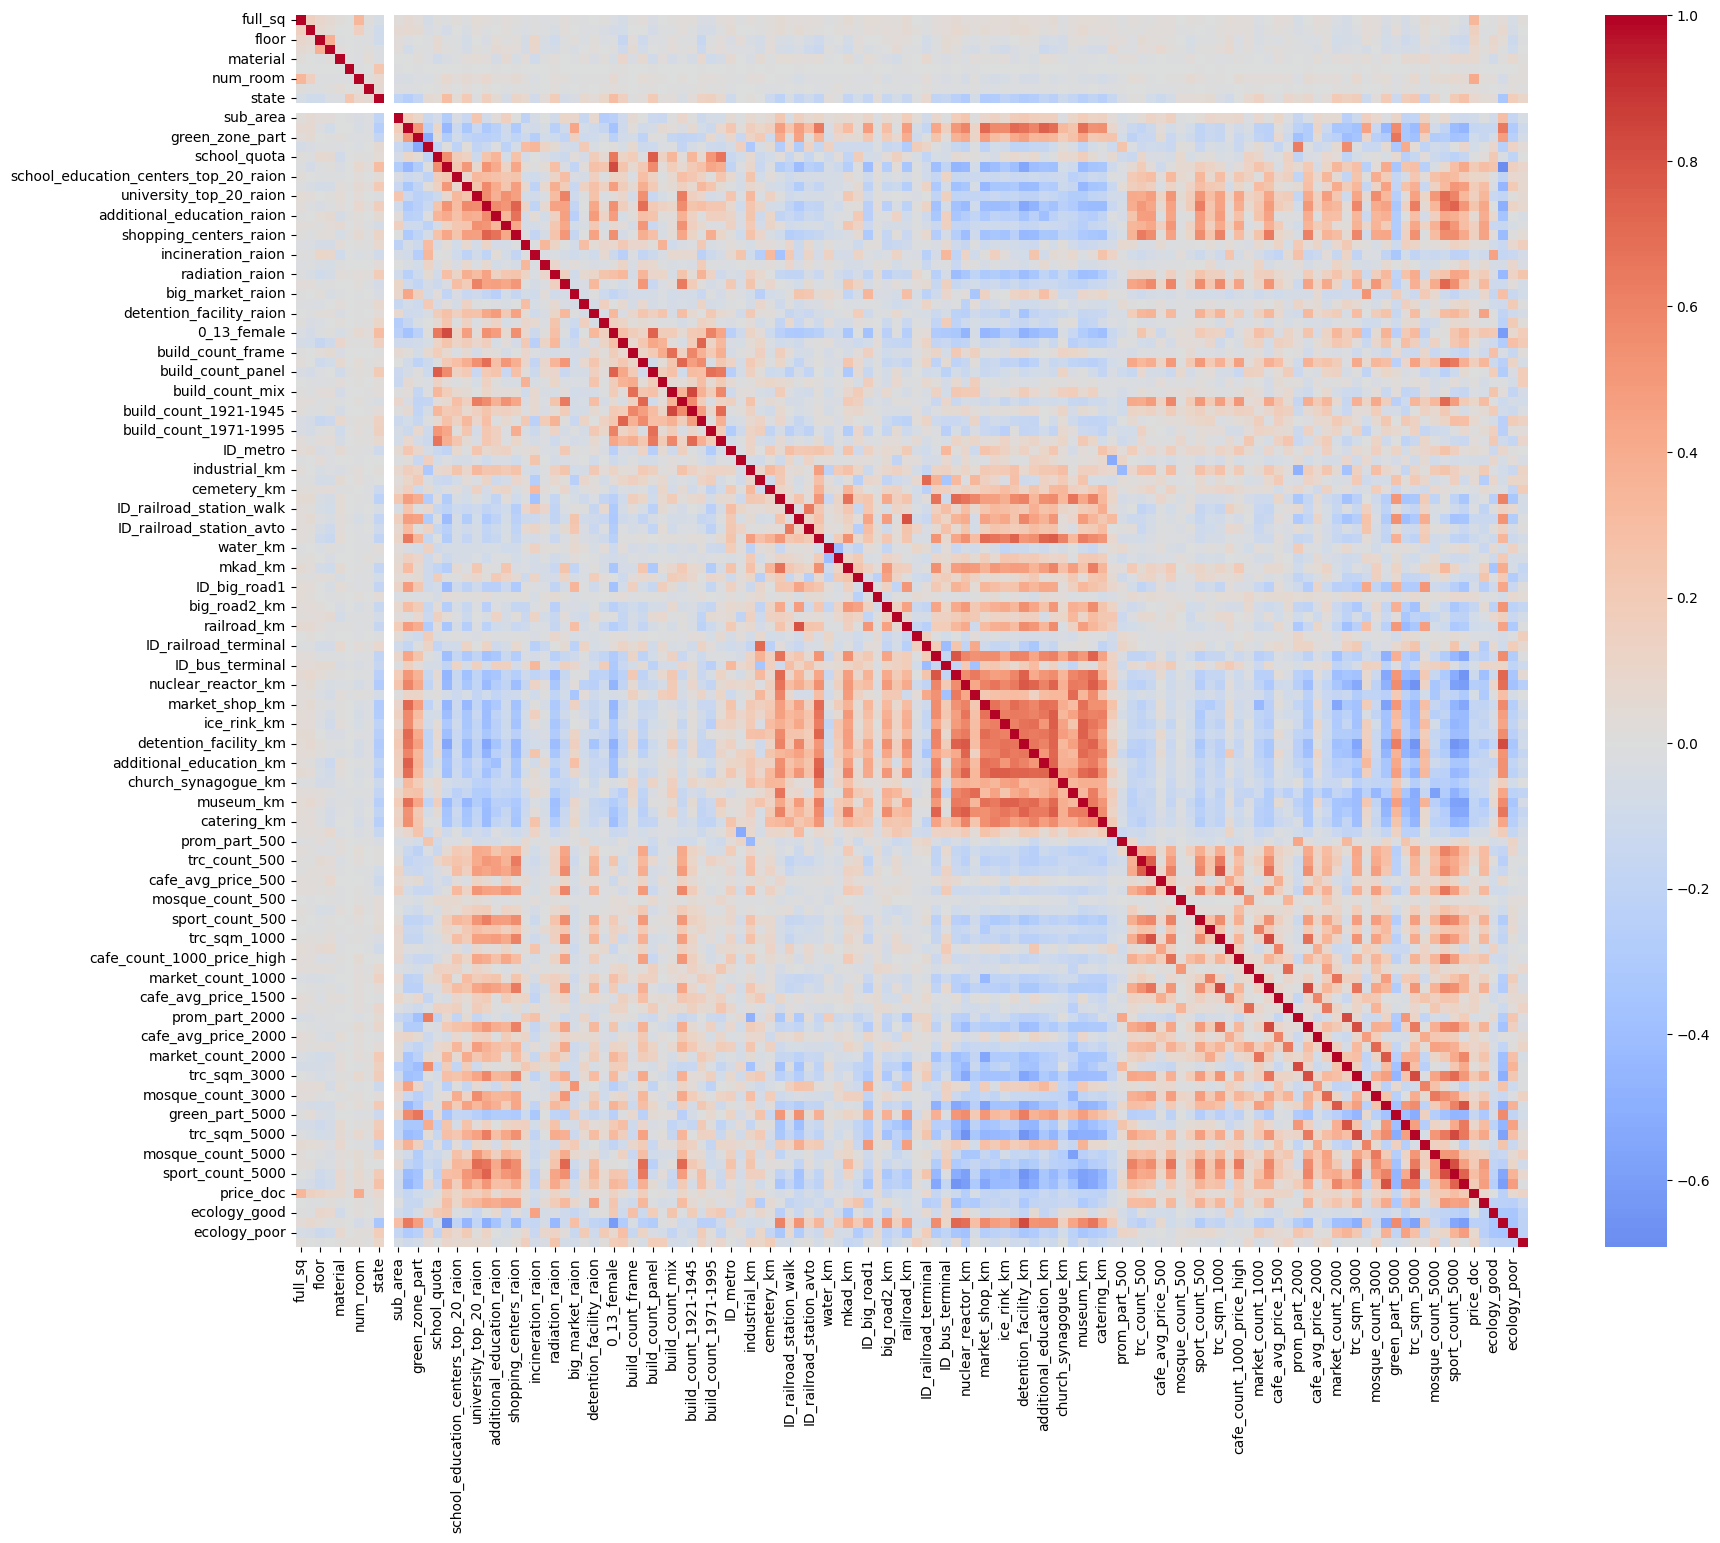

In [32]:
corr_matrix = data_train_v2.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, 
            cmap='coolwarm', 
            center=0,
            annot=False,
            square=True)
plt.show()

d.	Скэйлинг фичей

In [33]:
data_train_v2.head(5)

,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,product_type,...,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000,price_doc,ecology_excellent,ecology_good,ecology_no data,ecology_poor,ecology_satisfactory
0,43.0,27.0,4.0,13.707911,1.441979,1981.943134,1.854549,3.535776,2.421257,0,...,1.0,0.0,52.0,4.0,5850000.0,False,True,False,False,False
1,34.0,19.0,3.0,13.707911,1.441979,1981.943134,1.854549,3.535776,2.421257,0,...,1.0,10.0,66.0,14.0,6000000.0,True,False,False,False,False
2,43.0,29.0,2.0,13.707911,1.441979,1981.943134,1.854549,3.535776,2.421257,0,...,0.0,4.0,67.0,10.0,5700000.0,False,False,False,True,False
3,89.0,50.0,9.0,13.707911,1.441979,1981.598254,1.856756,3.535776,2.421257,0,...,0.0,0.0,26.0,3.0,13100000.0,False,True,False,False,False
4,77.0,77.0,4.0,13.707911,1.441979,1981.943134,1.854549,3.535776,2.421257,0,...,2.0,91.0,195.0,14.0,16331452.0,True,False,False,False,False


In [34]:
train_scale = data_train_v2.copy()
test_scale = data_test_v2.copy()

In [35]:
for col in train_scale.columns:
    if train_scale[col].dtypes == 'bool':
        train_scale[col] = train_scale[col].astype(int)

for col in test_scale.columns:
    if test_scale[col].dtypes == 'bool':
        test_scale[col] = test_scale[col].astype(int)


In [36]:
test_scale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7662 entries, 0 to 7661
Columns: 125 entries, full_sq to ecology_satisfactory
dtypes: float64(106), int64(19)
memory usage: 7.3 MB


In [37]:
train_scale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30471 entries, 0 to 30470
Columns: 126 entries, full_sq to ecology_satisfactory
dtypes: float64(107), int64(19)
memory usage: 29.3 MB


test_scale далее не используяю т к нет целевой колонки

In [54]:
target = train_scale['price_doc']

In [55]:
scaler_features = StandardScaler()
scaler_target = StandardScaler()

features_scaled = scaler_features.fit_transform(train_scale.drop('price_doc', axis=1))

target_scaled = scaler_target.fit_transform(target.values.reshape(-1, 1))

train_scaled = pd.DataFrame(
    features_scaled, 
    columns=train_scale.drop('price_doc', axis=1).columns,
    index=train_scale.index
)
train_scaled['price_doc'] = target_scaled

In [56]:
X = train_scaled.drop('price_doc', axis=1)
y = train_scaled['price_doc']

In [59]:
train_scaled.head()

,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,product_type,...,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000,ecology_excellent,ecology_good,ecology_no data,ecology_poor,ecology_satisfactory,price_doc
0,-0.294873,-0.205200,-0.690611,0.128662,-0.212332,-0.004459,-0.064771,-0.083784,0.393775,0.0,...,0.915176,-0.420245,-0.017208,-0.406425,-0.385252,1.80206,-0.579283,-0.597580,-0.370907,-0.266324
1,-0.531523,-0.374978,-0.879077,0.128662,-0.212332,-0.004459,-0.064771,-0.083784,0.393775,0.0,...,0.915176,0.065654,0.285221,1.638925,2.595705,-0.55492,-0.579283,-0.597580,-0.370907,-0.234943
2,-0.294873,-0.162756,-1.067542,0.128662,-0.212332,-0.004459,-0.064771,-0.083784,0.393775,0.0,...,-0.726162,-0.225885,0.306823,0.820785,-0.385252,-0.55492,-0.579283,1.673417,-0.370907,-0.297704
3,0.914671,0.282911,0.251717,0.128662,-0.212332,-0.004462,-0.061644,-0.083784,0.393775,0.0,...,-0.726162,-0.420245,-0.578861,-0.610960,-0.385252,1.80206,-0.579283,-0.597580,-0.370907,1.250402
4,0.599138,0.855911,-0.690611,0.128662,-0.212332,-0.004459,-0.064771,-0.083784,0.393775,0.0,...,2.556515,4.001437,3.071885,1.638925,2.595705,-0.55492,-0.579283,-0.597580,-0.370907,1.926434


5.	Строите полносвязную модель keras, можете добавить drop-out слои. Архитектура модели может быть любой, главное чтобы обучалась не слишком долго. Найдите баланс между качеством ответа и сложностью модели (начинайте с чего-то простого и усложняйте). При обучении вам нужно включить валидацию. Обучение должно проходить в 100 эпох. В конце обучения оцените переобучилась модель или нет (если на валидации качество не улучшается, а на тесте улучшается, то скорее всего переобучается)

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=5
)

In [84]:
from tensorflow import keras

from tensorflow.keras.layers import Dense, Dropout
import keras_tuner as tf

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [72]:
def create_model():
    model = keras.Sequential()
    
    model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dropout(0.4))
    
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.4))
    
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))
    
    model.add(Dense(16, activation='relu'))
    model.add(Dropout(0.2))
    
    model.add(Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss='mse',
        metrics=['mae'])
    
    return model

In [73]:
model = create_model()

c:\Users\Aleggg\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [74]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │        16,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,009 (105.50 KB)

 Trainable params: 27,009 (105.50 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/100
762/762 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.0193 - mae: 0.6171 - val_loss: 0.7411 - val_mae: 0.5282
Epoch 2/100
762/762 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8527 - mae: 0.5193 - val_loss: 0.6477 - val_mae: 0.4861
Epoch 3/100
762/762 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6897 - mae: 0.4830 - val_loss: 0.5527 - val_mae: 0.4485
Epoch 4/100
762/762 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6476 - mae: 0.4622 - val_loss: 0.5550 - val_mae: 0.4414
Epoch 5/100
762/762 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6024 - mae: 0.4476 - val_loss: 0.4979 - val_mae: 0.4100
Epoch 6/100
762/762 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5991 - mae: 0.4380 - val_loss: 0.4677 - val_mae: 0.4031
Epoch 7/100
762/762 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5769 - mae: 0.4282 - val_loss: 0.4855 - val_mae: 0.4044
Epoch 8/100
762/762 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5103 - mae: 0.4212 - val_loss: 0.4537 - val_mae: 0.3948
Epoch 9/100
762/762 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

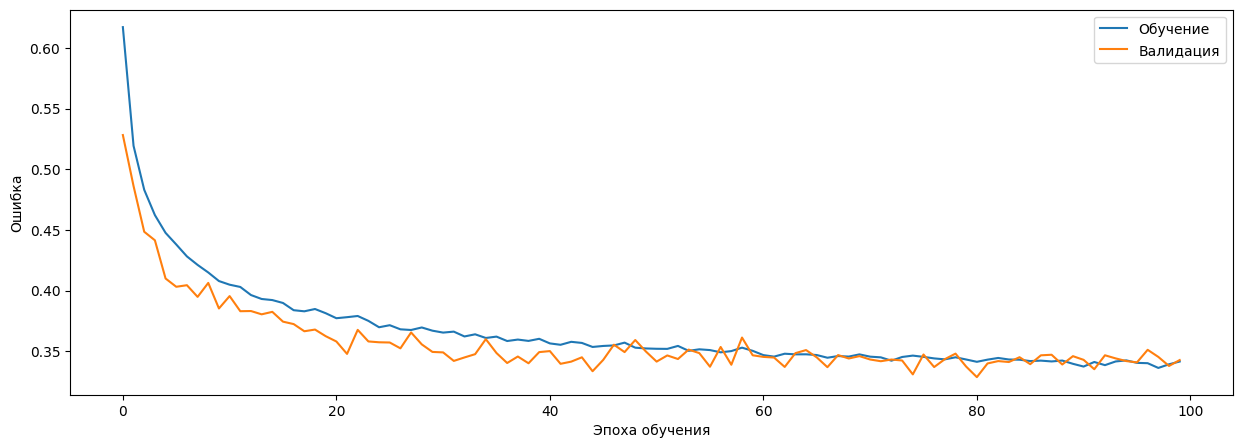

In [76]:
plt.figure(figsize=(15, 5))

plt.plot(history.history['mae'], label = 'Обучение')
plt.plot(history.history['val_mae'], label = 'Валидация')
plt.xlabel('Эпоха обучения')
plt.ylabel('Ошибка')
plt.legend()
plt.show()

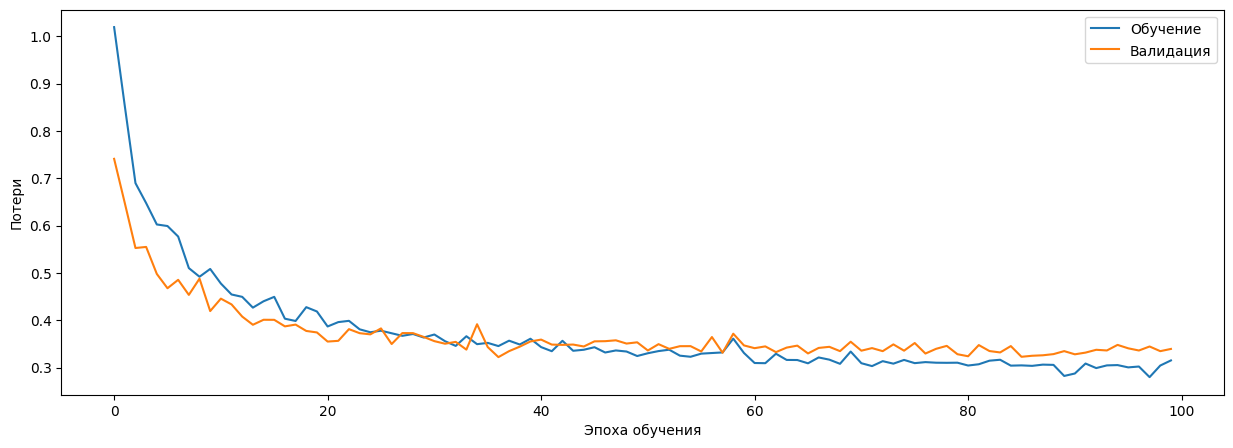

In [77]:
plt.figure(figsize=(15, 5))

plt.plot(history.history['loss'], label = 'Обучение')
plt.plot(history.history['val_loss'], label = 'Валидация')
plt.xlabel('Эпоха обучения')
plt.ylabel('Потери')
plt.legend()
plt.show()

In [79]:
print(f"train Loss: {history.history['loss'][-1]:.4f}")
print(f"val Loss: {history.history['val_loss'][-1]:.4f}")
print(f"train MAE: {history.history['mae'][-1]:.4f}")
print(f"val MAE: {history.history['val_mae'][-1]:.4f}")

train Loss: 0.3152
val Loss: 0.3395
train MAE: 0.3416
val MAE: 0.3428


In [80]:
y_pred = model.predict(X_test)

191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [86]:
y_test_original = scaler_target.inverse_transform(y_test.values.reshape(-1, 1))
y_pred_original = scaler_target.inverse_transform(y_pred)

In [87]:
mse = mean_squared_error(y_test_original, y_pred_original)
mae = mean_absolute_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)

In [89]:
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R^2: {r2:.4f}")

MSE: 7756306036946.15
MAE: 1638382.56
R^2: 0.6630


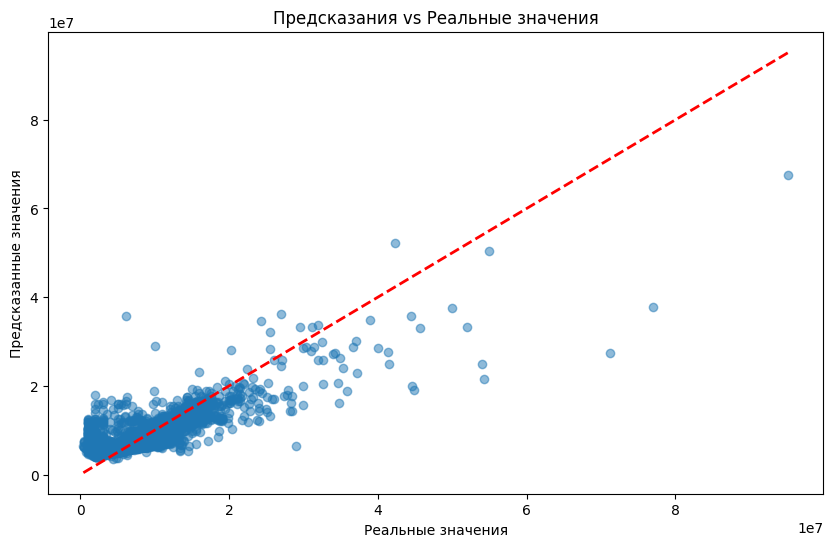

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test_original, y_pred_original, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 'r--', lw=2)
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title('Предсказания vs Реальные значения')
plt.show()

In [90]:
model.save('model.h5')

По работе можно сделать вывод:
1. модель не переобучена и хорошо работает с тестовыми данными:
- train Loss: 0.3152
- val Loss: 0.3395
- train MAE: 0.3416
- val MAE: 0.3428

2. модель предугадывает примерно 60%, но из минусов средняя ошибка составляет 1.6 млн деревянных что существенно, так же имеются выбросы:
- MSE: 7756306036946.15
- MAE: 1638382.56
- R^2: 0.6630

Могу предположит что модель так средне работает из за большого кол-во пропусков, и т к они являлись в основном ключевыми приходилось использовать заполнение. Так же если удалить процентов 30% с пропусками думаю модель может лучше работать.